In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('16-diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
columns_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'] 
for col in columns_to_replace :
    # Sütun adını (col) ve sayımı (count) yan yana yazdırıyoruz.
    print(f'--- \n{col} : {df[col][df[col] == 0].count()}')

--- 
Glucose : 5
--- 
BloodPressure : 35
--- 
SkinThickness : 227
--- 
Insulin : 374
--- 
BMI : 11


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# EDA : 

<Axes: xlabel='Outcome', ylabel='DiabetesPedigreeFunction'>

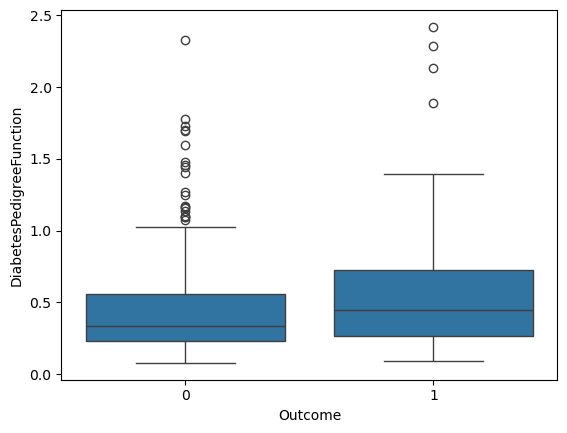

In [8]:
sns.boxplot(data = df , x = 'Outcome' , y = 'DiabetesPedigreeFunction')

<Axes: >

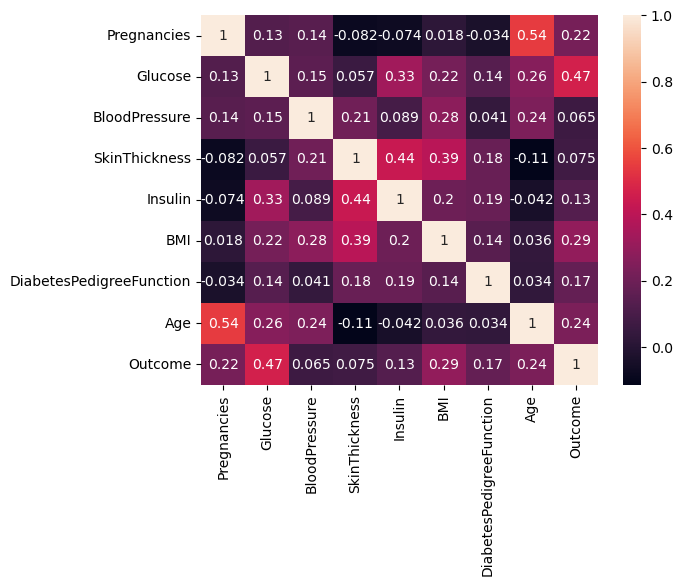

In [9]:
sns.heatmap(data = df.corr() , annot = True) 

In [10]:
X = df.drop(columns = 'Outcome' , axis = 1 )
y = df['Outcome']

from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 15)

In [11]:
for col in columns_to_replace : 
    median_values = X_train[X_train[col] != 0][col].median()
    X_train[col] = X_train[col].replace( 0 ,median_values )

for col in columns_to_replace :
    X_test[col] =  X_test[col].replace( 0 , median_values)

In [12]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,3.880208,121.633681,72.444444,28.991319,143.104167,32.384028,0.471340,33.260417
std,3.387120,30.063461,12.123009,8.188322,80.697328,6.726647,0.322218,11.623884
min,0.000000,44.000000,24.000000,7.000000,15.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.243250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,130.000000,32.000000,0.378000,29.000000
75%,6.000000,139.250000,80.000000,32.000000,130.000000,36.500000,0.637000,40.250000
max,17.000000,199.000000,122.000000,60.000000,680.000000,67.100000,2.288000,81.000000


In [13]:
from sklearn.preprocessing import RobustScaler

In [14]:
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train))
X_test_scaled = pd.DataFrame(scaler.transform(X_test))
X_train_scaled.head()

,0,1,2,3,4,5,6,7
0,-0.4,1.197452,0.625,2.000000,-12.6,0.089888,-0.093968,1.292308
1,0.8,-0.382166,0.125,1.571429,-5.0,0.584270,-0.441905,0.984615
2,0.2,0.127389,-0.250,0.000000,0.0,0.337079,0.040635,0.000000
3,0.4,-0.229299,0.000,2.000000,-11.0,0.460674,-0.292063,0.246154
4,1.4,-0.407643,0.250,2.714286,10.0,0.101124,-0.525714,2.092308


In [15]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier()
ada.fit(X_train , y_train)
y_pred = ada.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

print('Accuracy : \n' , accuracy_score(y_test , y_pred))
print('CF Report : \n' , classification_report(y_test , y_pred))
print('Conf Matrix : \n' , confusion_matrix(y_test , y_pred))

Accuracy : 
 0.7239583333333334
CF Report : 
               precision    recall  f1-score   support

           0       0.78      0.81      0.80       129
           1       0.59      0.54      0.56        63

    accuracy                           0.72       192
   macro avg       0.68      0.68      0.68       192
weighted avg       0.72      0.72      0.72       192

Conf Matrix : 
 [[105  24]
 [ 29  34]]


In [17]:
# Hyperparamether Tuning 

In [24]:
from sklearn.model_selection import GridSearchCV
ada_params = {
    'n_estimators' : [50 , 80 , 100 , 150 , 200 , 250],
    'learning_rate' : [1.0 , 2.0 , 5 ,10 , 7.5]
}

grid = GridSearchCV(estimator = AdaBoostClassifier() , param_grid = ada_params , cv = 5 , n_jobs = -1 )
grid.fit(X_train , y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [1.0, 2.0, 5, 10, 7.5],
                         'n_estimators': [50, 80, 100, 150, 200, 250]})

In [25]:
y_pred = grid.predict(X_test)
print('Accuracy : \n' , accuracy_score(y_test , y_pred))
print('CF Report : \n' , classification_report(y_test , y_pred))
print('Conf Matrix : \n' , confusion_matrix(y_test , y_pred))

Accuracy : 
 0.7291666666666666
CF Report : 
               precision    recall  f1-score   support

           0       0.77      0.86      0.81       129
           1       0.62      0.46      0.53        63

    accuracy                           0.73       192
   macro avg       0.69      0.66      0.67       192
weighted avg       0.72      0.73      0.72       192

Conf Matrix : 
 [[111  18]
 [ 34  29]]
